[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cyneuro/Chapter_Colabs/blob/main/Colab_B.ipynb)

# Set B — Cellular Models & Electrophysiology Basics
**Neural Engineering Laboratory, University of Missouri**

## Introduction
Welcome to the Cellular Modeling module. This lab is designed to move you from a qualitative understanding of neurons to a **quantitative appreciation** of how they function. We achieve this by exploring the spectrum of neural abstraction: from the computationally efficient **LIF** and **Izhikevich** models used in large-scale networks, to the biophysically detailed **Hodgkin-Huxley (HH)** equations that simulate actual ion channel kinetics.

By the end of this module, you will be able to map biological phenomena (like refractory periods and thresholding) to specific mathematical parameters and observe how measured physical signals can be used to drive simulated neural activity.

> ### ⚠️ Critical Path for Learners
> While the notebook begins with simplified models (B1-B2), these abstractions assume a firm grasp of electrophysiology principles. **It is strongly recommended that you complete the [B-Appendix: Electrophysiology Basics](#B-Appendix) PRIOR to beginning the contents in Set B.** The Appendix acts as your "Experimental Bench," where you will learn how to measure input resistance ($R_{in}$) and time constants ($\tau$) — concepts essential for interpreting the models in the main set.

## Table of Contents
* **[Introduction](#Introduction)** — Module overview and goals.
* **[🔰 B0 Starter](#B0-Starter)** — Environment setup (Run this first!).
* **[B-Appendix: Electrophysiology Basics](#B-Appendix)** — **Start Here** to learn the "Experimental Mindset."
* **[B1 Leaky Integrate-and-Fire (LIF)](#B1-LIF)** — The fundamental RC integrator.
* **[B2 Izhikevich Model](#B2-Izhikevich)** — Adding adaptation and bursting with low cost.
* **[B3 Hodgkin-Huxley via NEURON](#B3-HH)** — Detailed channel kinetics and biophysics.
* **[B4 Real-world Data Bridge](#B4-microbit)** — Mapping sensor data (micro:bit) to current clamp.
* **[Reflection & Discussion](#Reflection)** — Synthesizing biology-to-model mapping.

## 🔰 B0 Starter — Setup & Readiness Check
Before we begin, we must initialize the programming environment. This cell installs the `NEURON` simulator and ensures the necessary libraries are ready for the **Appendix** and **B3**.

### 💡 Pre-Flight Check
While the code below runs (it takes ~30 seconds), test your baseline knowledge:
1. **Compare Clamps:** In one sentence, what is the fundamental difference between **Current Clamp** and **Voltage Clamp**?
2. **Predict Dependency:** Which section of this notebook do you expect will fail if the `NEURON` package is not installed correctly?

*Once the output below says "NEURON is ready," proceed directly to the **[B-Appendix](#B-Appendix)**.*

In [1]:
# Install dependencies with quotes around the version constraint
!pip install -q neuron "numpy<2.1" matplotlib --upgrade

import neuron
from neuron import h
import numpy as np
import matplotlib.pyplot as plt

# Ensure standard run functions are available
h.load_file('stdrun.hoc')

print("NEURON is ready and functional.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 43.3 MB/s eta 0:00:00
NEURON is ready and functional.


## B1 — Leaky Integrate-and-Fire (LIF)

### Model Idea

Passive *RC integration* with a fixed spike threshold. This is the simplest quantitative representation of a neuron.

### Quantitative Check

Using the $R_{in}$ and $\tau$ values you calculated in the **[B-Appendix](#B-Appendix)**, observe how this simplified model matches the "biological" version.

### Predict → Verify

1. **Predict:** If you double the time constant ($\tau$), will the neuron require more or less frequent input pulses to reach the threshold?
2. **Verify:** Adjust the `tau` parameter in the code below and observe the change.

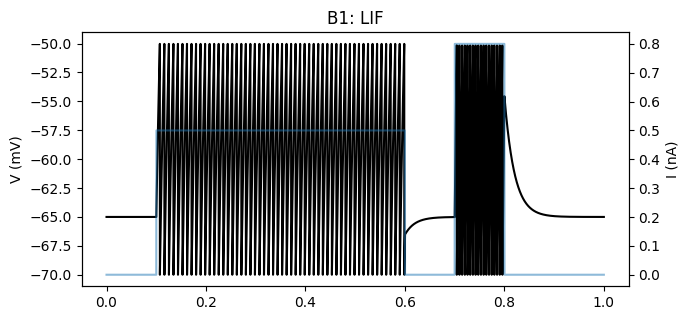

Spikes: 73


In [2]:

import numpy as np, matplotlib.pyplot as plt
V_rest=-65; V_th=-50; V_reset=-70; R=100.0; tau=20e-3
T=1.0; dt=1e-4; t=np.arange(0,T,dt)
I=np.zeros_like(t); I[(t>0.1)&(t<0.6)]=0.5; I[(t>0.7)&(t<0.8)]=0.8
V=np.ones_like(t)*V_rest; spikes=[]
for k in range(1,len(t)):
    dV = (-(V[k-1]-V_rest) + R*I[k-1])*(dt/tau)
    V[k] = V[k-1] + dV
    if V[k]>=V_th:
        spikes.append(t[k]); V[k]=V_reset
plt.figure(figsize=(7,3.3))
plt.plot(t,V,'k'); plt.ylabel('V (mV)'); plt.title('B1: LIF')
plt.twinx(); plt.plot(t,I,'C0',alpha=0.5); plt.ylabel('I (nA)')
plt.xlabel('Time (s)'); plt.tight_layout(); plt.show()
print('Spikes:', len(spikes))


## B2 — Izhikevich Model

### Model Idea

A slow recovery variable augments the voltage update to evoke adaptation or bursting with minimal computational cost.

### Useful Checks

* **Step Traces:** Under identical current, look for spike-frequency adaptation (ISIs getting longer).
* **Bursting:** Switch parameters to "Bursting" and identify the inter-burst interval.

### Predict → Verify

1. **Predict:** With *Regular Spiking (RS)* parameters, will the 1st and 5th ISIs be the same length?
2. **Verify:** Run the simulation and measure the distance between the first two spikes vs. the last two.

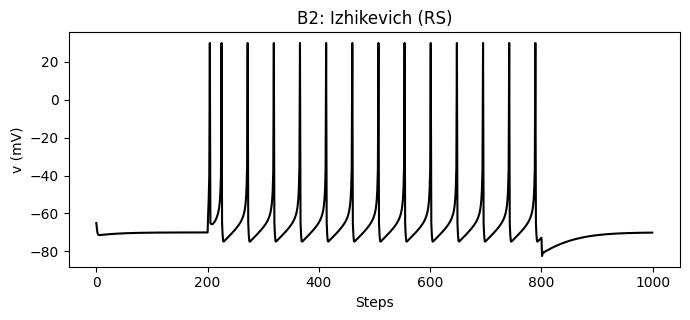

In [3]:

import numpy as np, matplotlib.pyplot as plt
# Regular spiking parameters
a,b,c,d = 0.02,0.2,-65,8
T=1000; I=np.zeros(T); I[200:800]=10
v=-65*np.ones(T); u=b*v
for k in range(1,T):
    dv = 0.04*v[k-1]**2 + 5*v[k-1] + 140 - u[k-1] + I[k-1]
    du = a*(b*v[k-1]-u[k-1])
    v[k] = v[k-1] + 0.5*dv; u[k] = u[k-1] + 0.5*du
    v[k] = v[k] + 0.5*dv;   u[k] = u[k] + 0.5*du
    if v[k]>=30:
        v[k-1]=30; v[k]=c; u[k]+=d
plt.figure(figsize=(7,3.3)); plt.plot(v,'k')
plt.title('B2: Izhikevich (RS)'); plt.xlabel('Steps'); plt.ylabel('v (mV)'); plt.tight_layout(); plt.show()


## B3 — HH via NEURON

### Model Idea

Biophysical $Na^+$ / $K^+$ conductances produce threshold and refractoriness from channel kinetics; waveforms reflect identifiable mechanisms.

### Useful Checks (Contrast with reduced models)

* **Latency:** How does the "first spike latency" change as you increase the input amplitude?
* **Refractoriness:** Observe the "Afterhyperpolarization" (the dip after the spike)—how does this limit the maximum firing rate?

### Predict → Verify

1. **Predict:** A modest increase in depolarizing current will shorten first-spike latency nonlinearly.
2. **Verify:** Increase the `stim.amp` in the code below and compare the time of the first spike peak to your previous run.

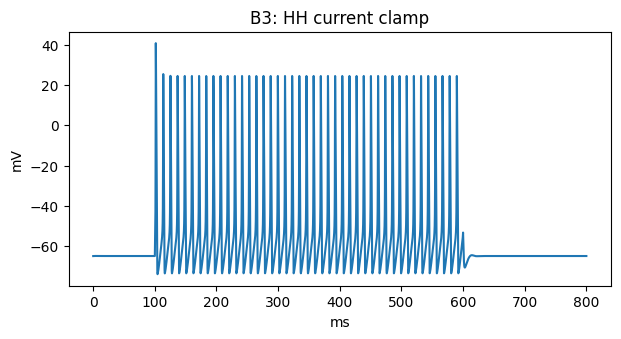

In [4]:

import numpy as np
import matplotlib.pyplot as plt
from neuron import h

# --- ADD THIS LINE ---
h.load_file('stdrun.hoc')
# ---------------------

soma = h.Section(name='soma')
soma.L = soma.diam = 12.6157
soma.insert('hh')

stim = h.IClamp(soma(0.5))
stim.delay = 100
stim.dur = 500
stim.amp = 0.1

v = h.Vector().record(soma(0.5)._ref_v)
t = h.Vector().record(h._ref_t)

h.finitialize(-65)
h.continuerun(800) # This will now work!


# Plotting
plt.figure(figsize=(7, 3.3))
plt.plot(t, v)
plt.title('B3: HH current clamp')
plt.xlabel('ms')
plt.ylabel('mV')
plt.show()

## B4 — micro:bit → Current Clamp (The Data Bridge)
### Idea
In the Appendix, you manually set current pulses. Here, we use real-world sensor data (like accelerometer movements) as the "stimulus" for your models. This maps a physical behavior to a simulated neural response.

### Useful Checks
* **Baseline:** Confirm the gray "accel" plot is centered around 0 after subtraction.
* **Spiking Logic:** Does a sharp movement in the physical data correspond to a burst of spikes in the model?

### Predict → Verify
1. **Predict:** Will the **HH model (B3)** handle the noisy sensor data differently than the **LIF model (B1)**?
2. **Verify:** Run the same sensor data through both and compare the "cleanliness" of the spike output.

In [5]:

import io, csv, numpy as np, matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload(); name=list(uploaded.keys())[0]
raw=uploaded[name].decode('utf-8'); rows=[r for r in csv.reader(io.StringIO(raw)) if len(r)>0]
try:
    _=[float(x) for x in rows[0]]; header=None
except Exception:
    header=rows[0]; rows=rows[1:]
import numpy as np
A=np.array([[float(x) for x in r[:2]] if len(r)>=2 else [np.nan,float(r[0])] for r in rows])
if np.isnan(A[:,0]).all():
    dt_ms=10.0; t_ms=np.arange(len(A))*dt_ms; accel=A[:,1]
else:
    t_ms=A[:,0]; accel=A[:,1]
baseline=np.percentile(accel,10); k=0.02
I = k*(accel-baseline); I[I<0]=0
plt.figure(figsize=(7,3)); plt.plot(t_ms,accel,'gray'); plt.title('accel (a.u.)'); plt.tight_layout(); plt.show()
plt.figure(figsize=(7,3)); plt.plot(t_ms,I,'C0'); plt.title('mapped I (nA)'); plt.tight_layout(); plt.show()


KeyboardInterrupt: 

## B-Appendix: Electrophysiology Basics

This appendix serves as your "Experimental Bench." While Sections B1–B4 focused on high-level abstractions, these exercises use the **NEURON environment** to explore the biophysical reality of how we measure and manipulate neurons.

## 🔬 The Experimental Mindset
In this section, you are the electrophysiologist. For each module (B-A.1 through B-A.6), you will find:
* ### Model Idea
  The biological or physical concept we are testing.
* ### Useful Checks
  Specific signal features you should look for in the plots to ensure the "rig" is working correctly.
* ### Predict → Verify
  A guided experiment where you must guess the outcome before running the code.

## 🛠️ Strategic Lab Guide
As you work through these basics, keep these "Troubleshooting" rules in mind for your later research:
1. **Too much "lag"?** If EPSPs are too broad in your models, revisit the **$\tau$** (Time Constant) measurements in **B-A.4**.
2. **Missing Spikes?** If a cell won't fire, check your **Rheobase** findings in **B-A.6**.
3. **Wrong Direction?** If inhibition is causing depolarization, check **$E_{rev}$** (Reversal Potential) in **B-A.5**.

*Student Note: Ensure you have run the **B0 Starter** cell at the top of this notebook, or the NEURON-based simulations in this appendix will not initialize.*

## B-A.1 — What does an intracellular electrode measure?

### Model Idea

Before simulating complex channels, we must understand the "Zero-Point." An electrode measures the potential difference between the salty interior of the cell and the grounded exterior. In this cell, we test how the membrane behaves when initialized at different voltages.

### Useful Checks
* **Initialization:** Notice how `h.finitialize(v0)` forces the cell to a specific voltage.
* **Relaxation:** After initialization, `h.continuerun(40)` allows the cell to drift. If there are no active currents, it should move toward the leak reversal potential ($e_{pas}$).

### Predict → Verify
1. **Predict:** If you "force" the cell to $-75$ mV, but its resting leak ($e_{pas}$) is $-65$ mV, will the voltage stay at $-75$ or move?
2. **Verify:** Run the cell. Look at the output list. Did the final voltages move closer to a specific "resting" value?

In [ ]:
from neuron import h
import numpy as np
import matplotlib.pyplot as plt

# Load standard simulation controls
h.load_file('stdrun.hoc')

# Placeholder: Create a cell if one isn't already in memory
# soma = h.Section(name='soma'); soma.insert('hh')

t_results = []
for v0 in [-75, -65, -55]:
    h.finitialize(v0)
    h.continuerun(40)
    t_results.append(v0)

print('Vm baseline depends on leak reversal & setup; this cell is a placeholder context note.')
print(f"Initial voltages tested: {t_results}")


## B-A.2 — Current clamp fundamentals

### Model Idea

Current clamp is like a "Volume Control" for flow. You specify the amount of current (nA) injected, and the membrane voltage ($V_m$) responds based on the cell's resistance and capacitance.

### Useful Checks
* **Ohm’s Law:** A positive (depolarizing) current should move $V_m$ upward.
* **Active vs. Passive:** Note which amplitudes in the sweep ($0.05$ to $0.15$ nA) trigger an action potential and which only produce a passive "bump."

### Predict → Verify
1. **Predict:** Which of the three positive current levels ($0.05$, $0.10$, $0.15$ nA) do you expect to be the **Rheobase** (the minimum current needed to fire a spike)?
2. **Verify:** Run the sweeps. Does the $0.05$ nA pulse produce a spike or just a sub-threshold depolarization?

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from neuron import h

# Essential for using h.continuerun
h.load_file('stdrun.hoc')

# Model setup
soma = h.Section(name='somaB')
soma.L = soma.diam = 20
soma.Ra = 100
soma.insert('hh')
soma.insert('pas')
soma.g_pas = 0.0002
soma.e_pas = -65

stim = h.IClamp(soma(0.5))
stim.delay = 5
stim.dur = 50

# Sweep through amplitudes
for A in [-0.05, 0.05, 0.10, 0.15]:
    stim.amp = A
    v = h.Vector().record(soma(0.5)._ref_v)
    t = h.Vector().record(h._ref_t)

    h.finitialize(-65)
    h.continuerun(70)

    plt.figure(figsize=(7, 3))
    plt.plot(t, v, 'k')
    plt.title(f'B-A.2: I-clamp amp={A} nA')
    plt.xlabel('ms')
    plt.ylabel('mV')
    plt.tight_layout()
    plt.show()

## B-A.3 — Voltage clamp fundamentals

### Model Idea

Voltage clamp is like a "Thermostat." You specify the target voltage (mV), and the amplifier injects whatever current ($I$) is necessary to hold it there. This allows us to "see" the opening and closing of ion channels as current flux.

### Useful Checks
* **Capacitive Transients:** Look for the sharp, vertical "spikes" in the current ($I$) plot at the exact moment the voltage steps change.
* **Inward vs. Outward:** Notice the downward dip (inward $Na^+$ flow) followed by a sustained upward flow (outward $K^+$ flow) during the steps.

### Predict → Verify
1. **Predict:** In the third stage (Step to $+40$ mV), will the sodium current ($Na^+$) still flow into the cell, or will it be pushed out because the voltage is so high?
2. **Verify:** Observe the direction of the early current peak in the final 20ms of the simulation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from neuron import h

# Load standard simulation controls (required for h.continuerun)
h.load_file('stdrun.hoc')

# Model setup
soma = h.Section(name='somaC')
soma.L = soma.diam = 20
soma.insert('hh')

# Voltage clamp protocol: 3 stages
vcl = h.VClamp(soma(0.5))
vcl.dur[0] = 10   # ms
vcl.amp[0] = -80  # mV
vcl.dur[1] = 20   # ms
vcl.amp[1] = -20  # mV
vcl.dur[2] = 20   # ms
vcl.amp[2] = 40   # mV

# Recording vectors
i = h.Vector().record(vcl._ref_i)
v = h.Vector().record(soma(0.5)._ref_v)
t = h.Vector().record(h._ref_t)

# Initialize and run
h.finitialize(-65)
h.continuerun(50)

# Plotting
plt.figure(figsize=(7, 4))

# Top plot: Voltage
plt.subplot(2, 1, 1)
plt.plot(t, v, 'k')
plt.ylabel('V (mV)')
plt.title('B-A.3 Voltage clamp protocol')

# Bottom plot: Current
plt.subplot(2, 1, 2)
plt.plot(t, i, 'C1')
plt.xlabel('ms')
plt.ylabel('I (nA)')

plt.tight_layout()
plt.show()



## B-A.4 — Estimating $R_{in}$ and $\tau$

### Model Idea

We use "Sub-threshold" pulses to characterize the physical "health" and size of the cell.

### Useful Checks
* **Input Resistance ($R_{in}$):** How "leaky" is the membrane?
* **Time Constant ($\tau$):** How "sluggish" is the membrane?

### Predict → Verify
1. **Predict:** If you make the cell larger (increase diameter), does $R_{in}$ go up or down?
2. **Verify:** Run the cell and record the baseline $R_{in}$.

In [ ]:

import numpy as np
from neuron import h

# Load standard simulation controls
h.load_file('stdrun.hoc')

# Model setup
soma = h.Section(name='somaR')
soma.L = soma.diam = 20
soma.Ra = 100
soma.insert('pas')
soma.g_pas = 0.0002
soma.e_pas = -65

# Stimulus setup
stim = h.IClamp(soma(0.5))
stim.amp = -0.03
stim.delay = 5
stim.dur = 30

# Recording vectors
v = h.Vector().record(soma(0.5)._ref_v)
t = h.Vector().record(h._ref_t)

# Run simulation
h.finitialize(-65)
h.continuerun(50)

# Analysis using NumPy
tnp = np.array(t)
vnp = np.array(v)

# Calculate Input Resistance (R_in)
ss = (tnp > 33) & (tnp < 38)
dV = vnp[ss].mean() - (-65)
Rin_MOhm = abs(dV) / abs(stim.amp)

# Estimate Time Constant (tau)
v0 = -65
vss = -65 + dV
target = v0 + 0.632 * (vss - v0)
idx = np.where(vnp >= target)[0]
tau_est = (tnp[idx[0]] - 5) if len(idx) > 0 else float('nan')

print(f'R_in ≈ {Rin_MOhm:.1f} MΩ; τ ≈ {tau_est:.2f} ms')



## B-A.5 — I–V Curve & Reversal Potential

### Model Idea

By plotting the steady-state current ($I$) against the commanded voltage ($V$), we create an **I-V Curve**. The point where the curve crosses zero ($I=0$) is the **Reversal Potential ($E_{rev}$)** — the voltage where there is no net flow of ions.

### Useful Checks
* **Linearity:** Is the curve a straight line (Passive/Ohmic) or does it curve upward (Active/Rectifying)?
* **Zero-Crossing:** Identify the voltage on the x-axis where the current on the y-axis is exactly $0$.

### Predict → Verify
1. **Predict:** Based on the `hh` mechanism inserted, do you expect the "resting" reversal potential to be closer to $-65$ mV or $0$ mV?
2. **Verify:** Look at the plot. At what voltage does the blue line cross the horizontal black line at $y=0$?

In [ ]:

from neuron import h
import numpy as np
import matplotlib.pyplot as plt

# Load standard simulation controls
h.load_file('stdrun.hoc')

# Model setup
soma = h.Section(name='somaIV')
soma.L = soma.diam = 20
soma.insert('hh')

# Voltage clamp protocol and I-V curve calculation
steps = [-90, -70, -50, -30, -10, 10, 30, 50]
I_ss = []

for Vc in steps:
    vcl = h.VClamp(soma(0.5))
    vcl.dur[0] = 5
    vcl.amp[0] = -80
    vcl.dur[1] = 30
    vcl.amp[1] = Vc
    vcl.dur[2] = 5
    vcl.amp[2] = -80

    i = h.Vector().record(vcl._ref_i)
    t = h.Vector().record(h._ref_t)

    h.finitialize(-65)
    h.continuerun(40)

    tnp = np.array(t)
    inp = np.array(i)

    # Sample steady-state current near the end of the step
    idx = (tnp >= 30) & (tnp <= 34)
    I_ss.append(inp[idx].mean())

# Plotting the I-V curve
plt.figure(figsize=(5, 3.8))
plt.plot(steps, I_ss, 'o-')
plt.axhline(0, color='k', lw=1)
plt.xlabel('Cmd V (mV)')
plt.ylabel('Steady I (nA)')
plt.title('B-A.5 I–V Curve')
plt.tight_layout()
plt.show()



## B-A.6 — Threshold, Rheobase, and Refractory Period

### Model Idea

Neurons aren't just batteries; they are "Excitable." This section explores the limits of that excitability.
* **Rheobase:** The minimum current to fire *one* spike.
* **Refractory Period:** The "recovery time" after a spike where a second stimulus cannot trigger another one.

### Useful Checks
* **Staircase (Part 1):** Watch how the "Latency to First Spike" shortens as the current (nA) increases.
* **Paired Pulses (Part 2):** Note the Inter-Stimulus Interval (ISI). If the ISI is too short, the second pulse fails to evoke a spike.

### Predict → Verify
1. **Predict:** In Part 2, what is the shortest interval (ISI) the cell needs before it is "ready" to fire a second time?
2. **Verify:** Run the paired-pulse sweep. At which ISI value does the second spike finally reappear?

In [ ]:

from neuron import h
import numpy as np
import matplotlib.pyplot as plt

# Load standard simulation controls (required for h.continuerun)
h.load_file('stdrun.hoc')

# --- PART 1: STAIRCASE ---
soma = h.Section(name='somaRheo')
soma.L = soma.diam = 20
soma.insert('hh')

amps = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12]
stim = h.IClamp(soma(0.5))
stim.delay = 5
stim.dur = 100

for A in amps:
    stim.amp = A
    v = h.Vector().record(soma(0.5)._ref_v)
    t = h.Vector().record(h._ref_t)

    h.finitialize(-65)
    h.continuerun(120)

    plt.figure(figsize=(6, 2.3))
    plt.plot(t, v, 'k')
    plt.title(f'B-A.6: Staircase A={A} nA')
    plt.tight_layout()
    plt.show()

# --- PART 2: PAIRED PULSES ---
# Create two independent clamps for the paired pulses
stim1 = h.IClamp(soma(0.5))
stim1.dur = 2
stim1.amp = 0.2

stim2 = h.IClamp(soma(0.5))
stim2.dur = 2
stim2.amp = 0.2

for isi in [2, 4, 6, 8, 10, 12]:
    stim1.delay = 5
    stim2.delay = 5 + isi

    v = h.Vector().record(soma(0.5)._ref_v)
    t = h.Vector().record(h._ref_t)

    h.finitialize(-65)
    h.continuerun(25)

    plt.figure(figsize=(6, 2.3))
    plt.plot(t, v, 'k')
    plt.title(f'B-A.6: ISI={isi} ms')
    plt.tight_layout()
    plt.show()


## Reflection & Synthesis

### Model Matching

Which model (LIF vs Izhikevich) best matches your **[B-Appendix](#B-Appendix)** measures? Justify your choice based on the voltage traces.

### Parametric Mapping

How do the $\tau$ and $R_{in}$ values you calculated in the Appendix manifest in the "Step Responses" of the models in B1 and B2?


## Practice / Discussion Questions — Set B — Biology → Model Mapping

1) Define a **model abstraction** for a neuron that preserves interpretability: which parameters must be in **biophysical units**, and why?
2) Explain how **blocks** (RC membrane, synaptic conductance, spike generator) can be composed into a testable single‑cell model.
3) *Justify*: What’s gained and lost when moving from detailed HH‑type to reduced spiking models?
4) How do you **document assumptions** so a reader can reproduce and critique your model? (List 3–4 items.)
5) What’s a **useful check** for a synapse implemented with a fixed reversal potential? (Describe the test and expected result.)
6) Outline a minimal **reproducible workflow** (notebook → plots → metrics) for a membrane step test.
7) Why is **parameter transparency** essential for educational modeling? Give one consequence of opaque scaling.
8) *Design*: Write 3 summary metrics you would log for “EPSP → spike coupling” experiments.
9) Choose one **modeling decision** (e.g., omit Ca²⁺) and argue when it’s acceptable for instruction.
10) What is the **role of NEURON** in enabling reproducibility for single cells and small networks?
11) *Compare*: When do you favor **current clamp** vs **conductance injection** to test a component?
12) Define a **minimal dendrite** you would include to capture location effects without overcomplicating the model.
13) What’s the educational **trade‑off** of adding noise sources to a beginner model?
14) How would you **validate** your inhibitory synapse timing motif before using it in a network?
15) *Scenario*: Your EPSPs look too broad. List 3 plausible causes and the diagnostic you’d run.
16) Why do we advocate **fixed random seeds** in notebooks for teaching?
17) Provide a **short rubric** for students to self‑assess whether their model description is reproducible by others.
18) Suggest two **figures** (plots/tables) that best communicate a membrane and synapse validation.
19) Give an example of a **missing mechanism** signaled by a consistent mismatch between model and data.
20) *Reflect*: What will you carry from Set B into Set C–E when you begin analyzing spatial effects?
